In [7]:
%matplotlib widget

Per ogni sorgente modificare:
- z e controllare che lambda lines corrisponda
- sigma e seeing
- n_component
- regione estrazione cielo
- taglio immagine in y
- funzioni di plot e model_convolved
- bounds_HA e bounds
- salvataggio fit

In [1]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
from astropy.modeling import models
from scipy.signal import convolve
from scipy.optimize import minimize
from astropy.convolution import Gaussian1DKernel
import scipy.integrate as integrate
from scipy.optimize import differential_evolution
import pandas as pd

In [2]:
hdul = fits.open("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/Mrk_1263/FORS2.2022-01-06T07_26_01.965/Mrk-1263_MAPPED_FLUX_SCI_LSS_U1.fits")
hdul.info()
image = hdul[0].data
image_error = hdul[1].data

Filename: C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/Mrk_1263/FORS2.2022-01-06T07_26_01.965/Mrk-1263_MAPPED_FLUX_SCI_LSS_U1.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     359   (2094, 964)   float32   
  1  IMAGE.ERR     1 ImageHDU        40   (2094, 964)   float32   


In [3]:
image_cut = image[56:156, 0:1890]
image_error_cut = image_error[56:156, 0:1890]

Text(0.5, 0, 'wavelength')

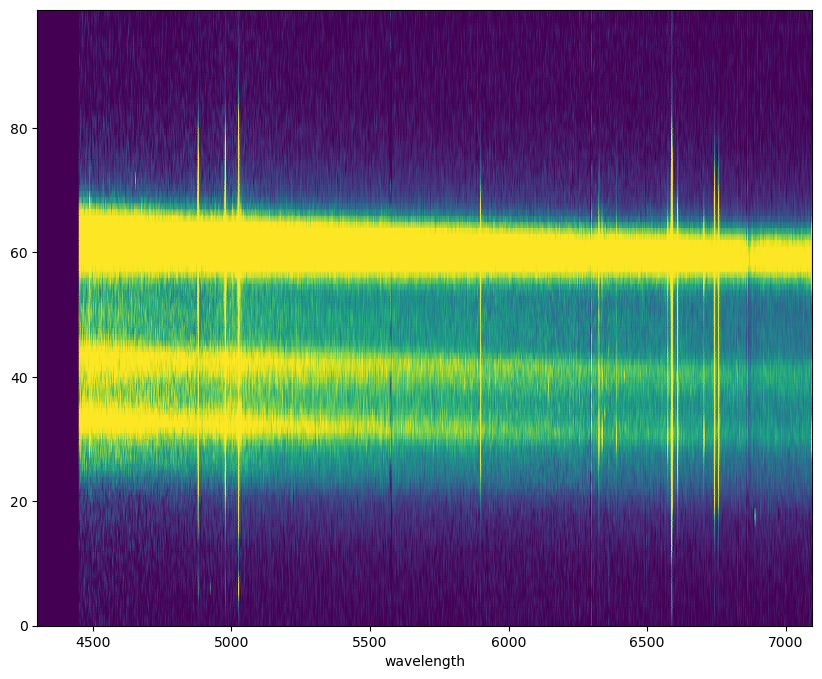

In [4]:
wv = np.arange(4300.74, 4300.74+1890*1.48, 1.48)
J, N = image_cut.data.shape
#x = np.arange(0, N, 1)
y = np.arange(0, J, 1)
arcsec_y = np.arange(-58*0.256, 42*0.256, 0.256)

x_grid, y_grid = np.meshgrid(wv, y)
plt.figure(figsize=(10,8))
plt.pcolormesh(x_grid, y_grid, image_cut, shading='gouraud', vmin=np.percentile(image_cut, 15), vmax=np.percentile(image_cut, 90))
plt.xlabel('wavelength')

## Redshift or the lines in air

In [5]:
z = 0.00442
l_HA = 6563 * (1+z)
l_HB = 4861 * (1+z) 
l_NII = 6583 * (1+z)
l_SII = 6717 * (1+z)
l_OIII = 5007 * (1+z)
seeing = 2.380
sigma = seeing / 2.35
n_component = 5

In [6]:
l_HA

6592.008460000001

## Sky lines

Filename: C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/Mrk_1263/FORS2.2022-01-06T07_26_01.965/Mrk-1263_MAPPED_FLUX_ALL_SCI_LSS_U1.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     359   (2094, 964)   float32   
  1  IMAGE.ERR     1 ImageHDU        40   (2094, 964)   float32   


Text(0.5, 0, 'wavelength')

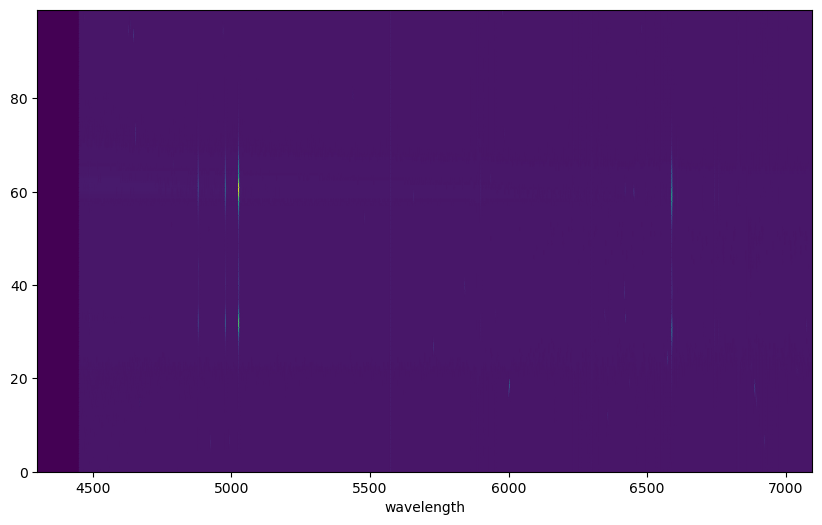

In [7]:
hdul2 = fits.open("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/Mrk_1263/FORS2.2022-01-06T07_26_01.965/Mrk-1263_MAPPED_FLUX_ALL_SCI_LSS_U1.fits")
hdul2.info()
image2 = hdul2[0].data
image_cut2 = image2[56:156, 0:1890]

x_grid, y_grid = np.meshgrid(wv, y)
plt.figure(figsize=(10, 6))
plt.pcolormesh(x_grid, y_grid, image_cut2, shading='gouraud')#, vmin = np.percentile(image_cut, 20), vmax = 0.16)
plt.xlabel('wavelength')

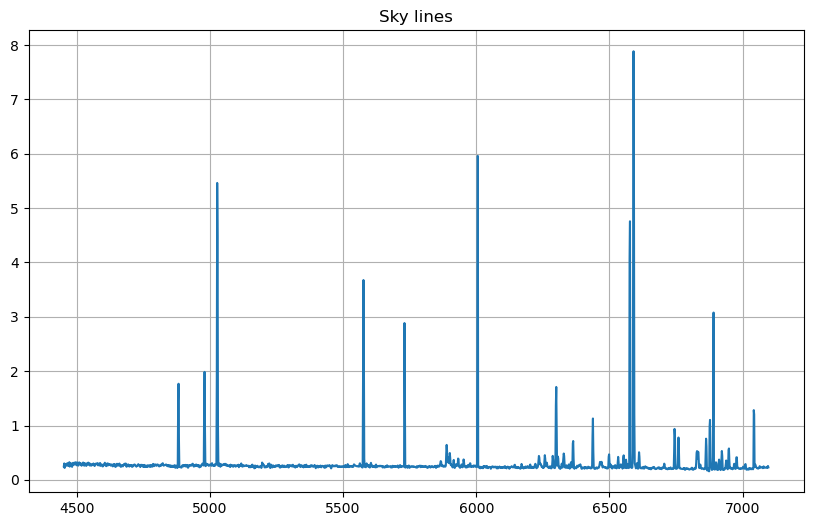

In [8]:
mask_sky = (y > 18)*(y < 28)
mask_wv = wv > 4450.5
image_sky = image_cut2[np.ix_(mask_sky, mask_wv)]
radial_profile_sky = np.sum(image_sky, axis = 0)
plt.figure(figsize=(10, 6))
plt.plot(wv[mask_wv], radial_profile_sky)

plt.grid()
plt.title(r'Sky lines')

plt.savefig('Sky_lines')

## H$\alpha$

Text(0.5, 1.0, 'H$\\alpha$')

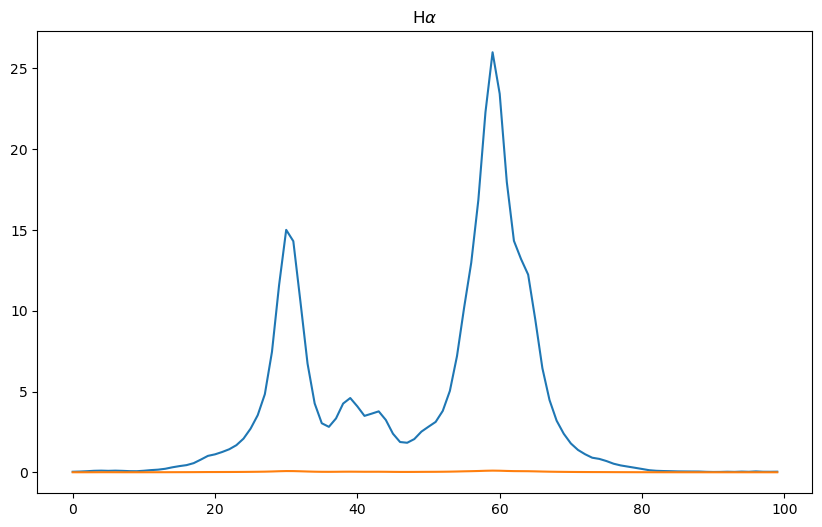

In [9]:
mask_HA = (wv > l_HA-8)*(wv < l_HA+8)
image_HA = image_cut[:, mask_HA]
image_error_HA = image_error_cut[:, mask_HA]
radial_profile_HA = np.sum(image_HA, axis = 1)
radial_profile_error_HA = np.sqrt(np.sum(image_error_HA**2, axis = 1))

x_axes = np.arange(0, 100, 1)
plt.figure(figsize=(10, 6))
plt.plot(x_axes, radial_profile_HA)
plt.plot(x_axes, radial_profile_error_HA)
plt.title(r'H$\alpha$')

In [64]:
def calculate_bn(n):
    """ Calcola b_n per il profilo Sérsic """
    return 2*n - 1/3 + 4/(405*n) + 46/(25515*n**2)

def sersic_1d(x, I_e, r_e, n, x_0):
    """ Profilo Sérsic 1D centrato in x_0 """
    r = np.abs(x - x_0)
    b_n = calculate_bn(n)
    return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))

def model_convolved(x, *params):
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = (
        sersic_1d(x_hr, *params[0:4]) +
        sersic_1d(x_hr, *params[4:8]) +
        sersic_1d(x_hr, *params[8:12]) +
        sersic_1d(x_hr, *params[12:16]) +
        sersic_1d(x_hr, *params[16:20]) #+
        #sersic_1d(x_hr, *params[20:24])
    )
    kernel = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')   
    conv_profile = convolve(profile, kernel, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def chi_squared(params, x, y_obs):
    y_model = model_convolved(x, *params)
    return np.sum((y_obs - y_model)**2)

def sersic_1d_convolved(x, I_e, r_e, n, x_0):
    """ Sérsic convoluto con PSF gaussiana """
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = sersic_1d(x_hr, I_e, r_e, n, x_0)
    psf = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')
    conv_profile = convolve(profile, psf, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def plot_curve(x_axes, params_curve, radial_profile, title = ""):
    y_fit = model_convolved(x_axes, *params_curve)
    fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

    ax[0].plot(x_axes, radial_profile, label='Data')
    ax[0].plot(x_axes, y_fit, 'r-', label='Fit')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[0:4]), 'b--', label='Sérsic 1')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[4:8]), 'g--', label='Sérsic 2')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[8:12]), 'm--', label='Sérsic 3')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[12:16]), color='orange', linestyle='--', label='Sérsic 4')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[16:20]), color = 'chocolate', linestyle='--', label='Sérsic 5')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[20:24]), color = 'purple', linestyle='--', label='Sérsic 6')

    ax[0].set_xlabel("Pixel")
    ax[0].set_ylabel(r'Flux [$10^{-16} erg/(cm^2 s \AA )$]')
    ax[0].set_title(title)
    ax[0].legend()
    ax[0].grid(True)
    ax[0].set_ylim(0, 45)
    #ax[0].tight_layout()
    
    ax[1].scatter(x_axes, (radial_profile - y_fit)/radial_profile_error_HA, marker = '+')
    ax[1].axhline(0, color ='red', linestyle ='dashed')
    ax[1].set_ylabel(r'$\chi$')

def plot_diff(x_axes, best_params, radial_profile, title = ""):
    y_fit = model_convolved(x_axes, *best_params)

    fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

    ax[0].plot(x_axes, radial_profile, label='Data')
    ax[0].plot(x_axes, y_fit, 'r-', label='Fit')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[0:4]), 'b--', label='Sérsic 1')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[4:8]), 'g--', label='Sérsic 2')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[8:12]), 'm--', label='Sérsic 3')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[12:16]), color='orange', linestyle='--', label='Sérsic 4')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[16:20]), color = 'chocolate', linestyle='--', label='Sérsic 5')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[20:24]), color = 'purple', linestyle='--', label='Sérsic 6')

    ax[0].set_xlabel("Pixel")
    ax[0].set_ylabel(r'Flux [$10^{-16} erg/(cm^2 s \AA )$]')
    ax[0].set_title(title)
    ax[0].legend()
    ax[0].grid(True)
    ax[0].set_ylim(0, 45)
    #ax[0].tight_layout()
    
    ax[1].plot(x_axes, radial_profile - y_fit)
    ax[1].set_ylim(-0.2, 0.2)

bounds_HA = [
    (0, 1),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (25, 35),   # x_0: posizione da 0 a 100

    (0, 1),
    (0, 50),
    (0.1, 10),
    (35, 40),

    (0, 1),
    (0, 50),
    (0.1, 10),
    (40, 45),

    (0, 1),
    (0, 50),
    (0.1, 10),
    (55, 63),

    (0, 1),
    (0, 50),
    (0.1, 10),
    (60, 65)
]

def save_params(params_curve, covariance, radial_profile, radial_profile_error, x_axes, n_component, line_name="", output_prefix="fit"):
    I_e = np.zeros(n_component)
    r_e = np.zeros(n_component)
    n = np.zeros(n_component)
    x_0 = np.zeros(n_component)

    I_e_err = np.zeros(n_component)
    r_e_err = np.zeros(n_component)
    n_err = np.zeros(n_component)
    x_0_err = np.zeros(n_component)

    for i in range(n_component):
        I_e[i], r_e[i], n[i], x_0[i] = params_curve[i*4:(i+1)*4]
        I_e_err[i] = np.sqrt(np.diag(covariance)[i*4])
        r_e_err[i] = np.sqrt(np.diag(covariance)[(i*4)+1])
        n_err[i] = np.sqrt(np.diag(covariance)[(i*4)+2])
        x_0_err[i] = np.sqrt(np.diag(covariance)[(i*4)+3])
        print(f"Sérsic {i+1}: I_e={I_e[i]:.4f}, r_e={r_e[i]:.4f}, n={n[i]:.4f}, x_0={x_0[i]:.4f}")

    print(np.sqrt(np.diag(covariance)))
    chi2 = np.sum((((radial_profile - model_convolved(x_axes, *params_curve)) / radial_profile_error)**2))
    dof = len(radial_profile) - len(params_curve)
    chi2_reduced = chi2 / dof
    print(chi2_reduced)

    param_dict = {}
    error_dict = {}
    
    for i in range(n_component):
        component_name = f'Component {i+1}'
        param_dict[component_name] = [I_e[i], r_e[i], n[i], x_0[i]]
        error_dict[component_name] = [I_e_err[i], r_e_err[i], n_err[i], x_0_err[i]]
    
    # Crea DataFrame
    df_params = pd.DataFrame(data=param_dict, index=['I_e', 'r_e', 'n', 'x_0'])
    df_errors = pd.DataFrame(data=error_dict, index=['I_e error', 'r_e error', 'n error', 'x_0 error'])
    
    # Salva file CSV
    if line_name:
        param_filename = f"{line_name}_{output_prefix}.csv"
        error_filename = f"{line_name}_{output_prefix}_errors.csv"
    
    df_params.to_csv(param_filename, float_format='%.4f')
    df_errors.to_csv(error_filename, float_format='%.4f')
    return chi2_reduced, dof, chi2

In [11]:
# Bounds:
bounds = bounds_HA

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_HA)

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 1590.0894449145073
differential_evolution step 2: f(x)= 1140.3470841873348
differential_evolution step 3: f(x)= 974.4805113664759
differential_evolution step 4: f(x)= 943.3961731673174
differential_evolution step 5: f(x)= 889.9031656522187
differential_evolution step 6: f(x)= 624.4156044858298
differential_evolution step 7: f(x)= 624.4156044858298
differential_evolution step 8: f(x)= 624.4156044858298
differential_evolution step 9: f(x)= 624.4156044858298
differential_evolution step 10: f(x)= 624.4156044858298
differential_evolution step 11: f(x)= 624.4156044858298
differential_evolution step 12: f(x)= 557.2613377489407
differential_evolution step 13: f(x)= 314.22626016101066
differential_evolution step 14: f(x)= 314.22626016101066
differential_evolution step 15: f(x)= 314.22626016101066
differential_evolution step 16: f(x)= 314.22626016101066
differential_evolution step 17: f(x)= 314.22626016101066
differential_evolution step 18: f(x)= 314.22626016

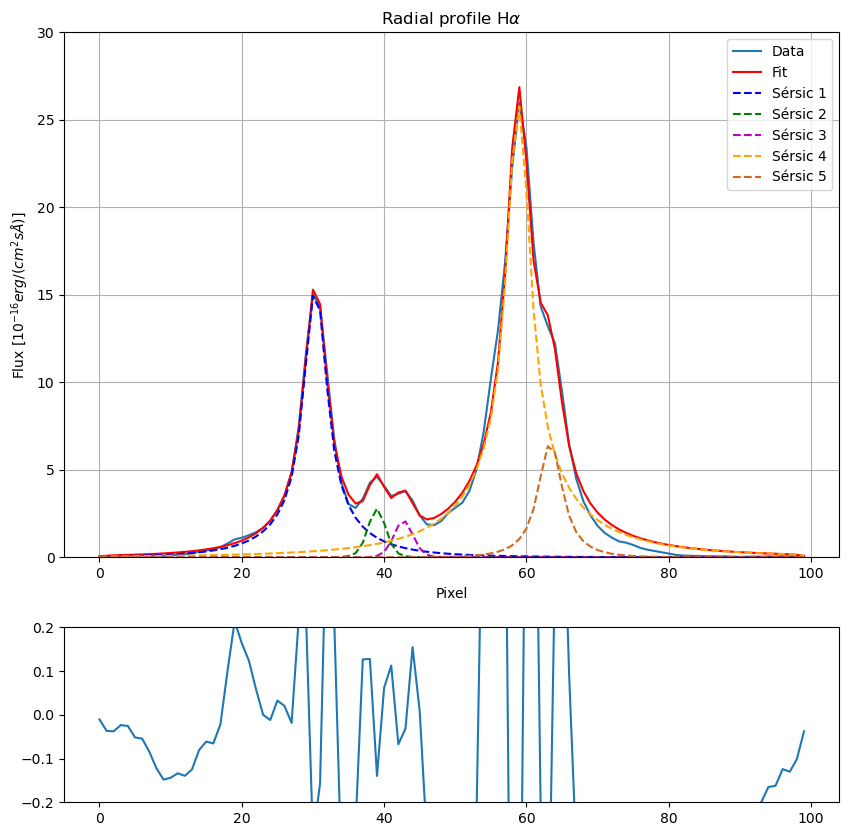

In [19]:
plot_diff(x_axes, best_params, radial_profile_HA, r"Radial profile H$\alpha$")
plt.savefig('Radial_profile_Halpha_diff')

In [20]:
params_curve_HA, covariance_HA = curve_fit(model_convolved, x_axes, radial_profile_HA, p0=result.x, sigma = radial_profile_error_HA)

print("Optimize parameters with curve fit:")

chi2_reduced_HA, dof_HA, chi2_HA = save_params(params_curve_HA, covariance_HA, radial_profile_HA, radial_profile_error_HA,
    x_axes, n_component, line_name="Halpha", output_prefix="fit")

C:\Users\ISAFA\AppData\Local\Temp\ipykernel_1448\3937479226.py:9: RuntimeWarning: invalid value encountered in power
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))
C:\Users\ISAFA\AppData\Local\Temp\ipykernel_1448\3937479226.py:9: RuntimeWarning: overflow encountered in exp
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))
C:\Users\ISAFA\AppData\Local\Temp\ipykernel_1448\3937479226.py:22: RuntimeWarning: Use of fft convolution on input with NAN or inf results in NAN or inf output. Consider using method='direct' instead.
  conv_profile = convolve(profile, kernel, mode='same')
C:\Users\ISAFA\anaconda3\Lib\site-packages\scipy\signal\_signaltools.py:511: RuntimeWarning: invalid value encountered in multiply
  ret = ifft(sp1 * sp2, fshape, axes=axes)


Optimize parameters with curve fit:
Sérsic 1: I_e=1.1341, r_e=8.9418, n=1.8649, x_0=30.3263
Sérsic 2: I_e=2.1390, r_e=1.4120, n=0.0615, x_0=38.8654
Sérsic 3: I_e=0.7333, r_e=2.6935, n=1.0779, x_0=42.8275
Sérsic 4: I_e=4.3188, r_e=6.5259, n=1.2051, x_0=58.9996
Sérsic 5: I_e=0.1811, r_e=9.2945, n=2.6974, x_0=64.0921
[1.13909328e-01 4.83928498e-01 1.44406673e-01 7.84268947e-03
 1.00337077e+02 1.15858213e+01 2.87767415e+00 1.72365004e-01
 5.50951181e-01 1.21696655e+00 5.81989757e-01 2.34339513e-01
 3.56881049e-01 3.88964235e-01 6.13885319e-02 5.14613920e-02
 1.30546614e-01 4.97426835e+00 5.46846295e-01 1.18078088e-01]
23.393835577526993


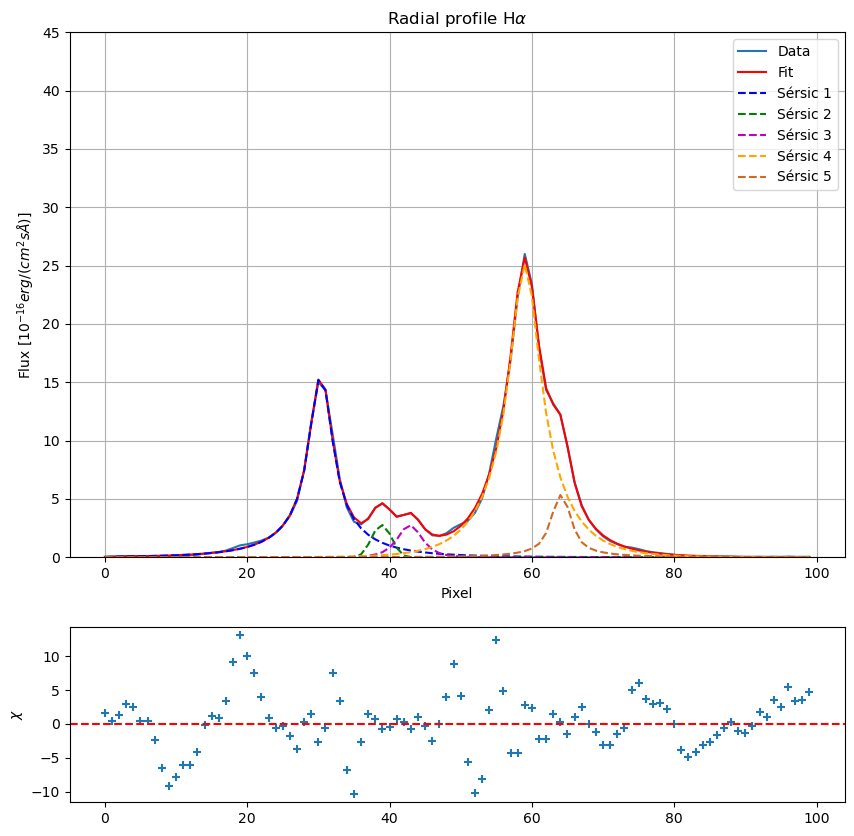

In [65]:
plot_curve(x_axes, params_curve_HA, radial_profile_HA, r"Radial profile H$\alpha$")
plt.savefig('Radial_profile_Halpha_curve')

In [22]:
fit_HA = pd.read_csv("Halpha_fit.csv", index_col=0)
x_0_HA = fit_HA.iloc[3].values
bounds = [
    (0, 1),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (x_0_HA[0]-(seeing/2), x_0_HA[0]+(seeing/2)),   # x_0: posizione da 0 a 100

    (0, 1),
    (0, 50),
    (0.1, 10),
    (x_0_HA[1]-(seeing/2), x_0_HA[1]+(seeing/2)),

    (0, 1),
    (0, 50),
    (0.1, 10),
    (x_0_HA[2]-(seeing/2), x_0_HA[2]+(seeing/2)),

    (0, 1),
    (0, 50),
    (0.1, 10),
    (x_0_HA[3]-(seeing/2), x_0_HA[3]+(seeing/2)),

    (0, 1),
    (0, 50),
    (0.1, 10),
    (x_0_HA[4]-(seeing/2), x_0_HA[4]+(seeing/2))

]

## H$\beta$

Text(0.5, 1.0, 'H$\\beta$')

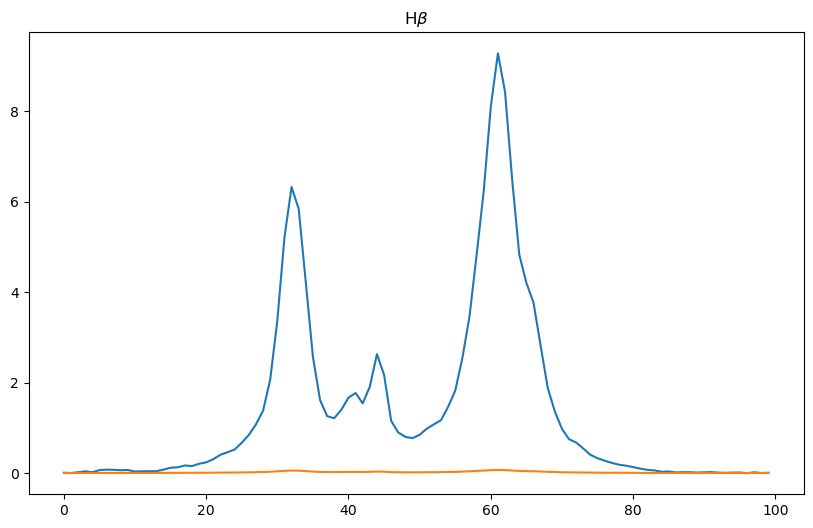

In [23]:
mask_HB = (wv > l_HB-8)*(wv < l_HB+8)
image_HB = image_cut[:, mask_HB] 
image_error_HB = image_error_cut[:, mask_HB]
radial_profile_HB = np.sum(image_HB, axis = 1)
radial_profile_error_HB = np.sqrt(np.sum(image_error_HB**2, axis = 1))

plt.figure(figsize=(10, 6))
x_axes = np.arange(0, 100, 1)
plt.plot(x_axes, radial_profile_HB)
plt.plot(x_axes, radial_profile_error_HB)
plt.title(r'H$\beta$')

In [24]:
# Bounds:
bounds = bounds

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_HB)

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 354.4752833618759
differential_evolution step 2: f(x)= 199.91478329774412
differential_evolution step 3: f(x)= 199.91478329774412
differential_evolution step 4: f(x)= 107.88229694633264
differential_evolution step 5: f(x)= 107.88229694633264
differential_evolution step 6: f(x)= 107.88229694633264
differential_evolution step 7: f(x)= 107.88229694633264
differential_evolution step 8: f(x)= 107.88229694633264
differential_evolution step 9: f(x)= 107.88229694633264
differential_evolution step 10: f(x)= 107.88229694633264
differential_evolution step 11: f(x)= 80.50262792563596
differential_evolution step 12: f(x)= 73.57069682090139
differential_evolution step 13: f(x)= 73.57069682090139
differential_evolution step 14: f(x)= 73.57069682090139
differential_evolution step 15: f(x)= 73.57069682090139
differential_evolution step 16: f(x)= 73.57069682090139
differential_evolution step 17: f(x)= 73.57069682090139
differential_evolution step 18: f(x)= 73.5706968

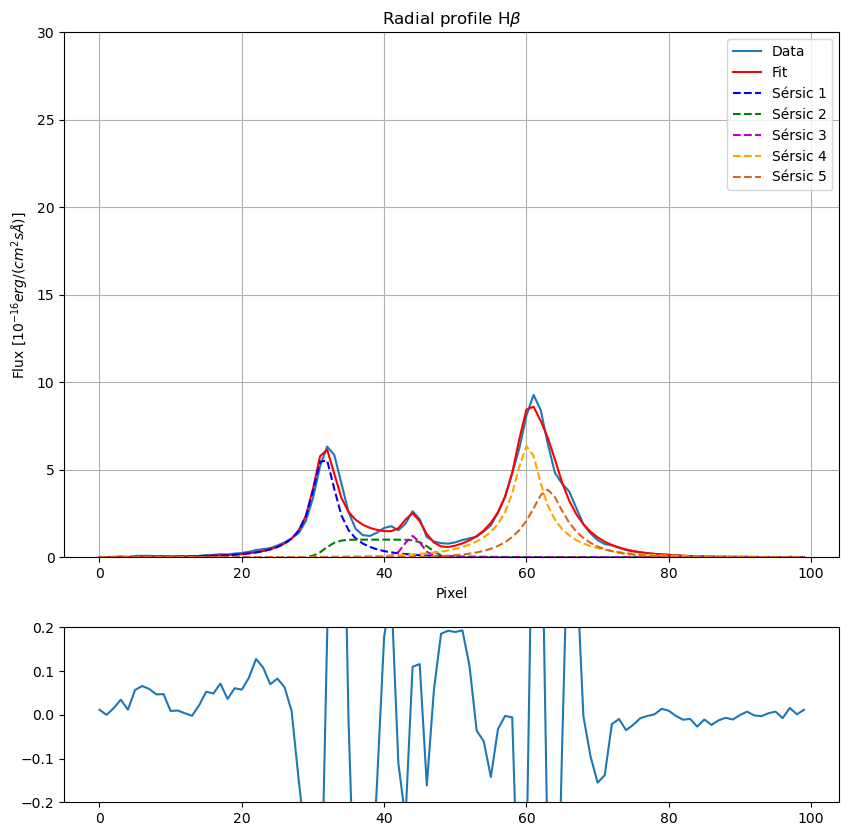

In [25]:
plot_diff(x_axes, best_params, radial_profile_HB, r"Radial profile H$\beta$")
plt.savefig('Radial_profile_Hbeta_diff')

In [26]:
params_curve_HB, covariance_HB = curve_fit(model_convolved, x_axes, radial_profile_HB, p0=result.x, sigma = radial_profile_error_HB)

chi2_reduced_HB, dof_HB, chi2_HB = save_params(params_curve_HB, covariance_HB, radial_profile_HB, radial_profile_error_HB,
    x_axes, n_component, line_name="Hbeta", output_prefix="fit")

C:\Users\ISAFA\AppData\Local\Temp\ipykernel_1448\3937479226.py:9: RuntimeWarning: overflow encountered in exp
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))
C:\Users\ISAFA\anaconda3\Lib\site-packages\scipy\signal\_signaltools.py:511: RuntimeWarning: invalid value encountered in multiply
  ret = ifft(sp1 * sp2, fshape, axes=axes)
C:\Users\ISAFA\AppData\Local\Temp\ipykernel_1448\3937479226.py:22: RuntimeWarning: Use of fft convolution on input with NAN or inf results in NAN or inf output. Consider using method='direct' instead.
  conv_profile = convolve(profile, kernel, mode='same')
C:\Users\ISAFA\AppData\Local\Temp\ipykernel_1448\3937479226.py:9: RuntimeWarning: overflow encountered in power
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))


Sérsic 1: I_e=0.2603, r_e=11.5887, n=2.3216, x_0=32.1227
Sérsic 2: I_e=0.0264, r_e=7.0779, n=0.0265, x_0=35.6545
Sérsic 3: I_e=0.1204, r_e=6.4788, n=2.2409, x_0=44.0165
Sérsic 4: I_e=1.1117, r_e=7.8721, n=1.3234, x_0=61.0590
Sérsic 5: I_e=0.6583, r_e=5.3738, n=0.0542, x_0=62.5136
[ 0.06968751  2.06340411  0.21585472  0.06460624  2.89542556  2.34983523
  0.53177647  0.73482326  0.46859169 16.10225498  4.58945278  0.02067539
  0.13855407  0.43102917  0.07351277  0.08449508  3.29922168  2.74513639
  0.200145    0.23835378]
13.511662867546814


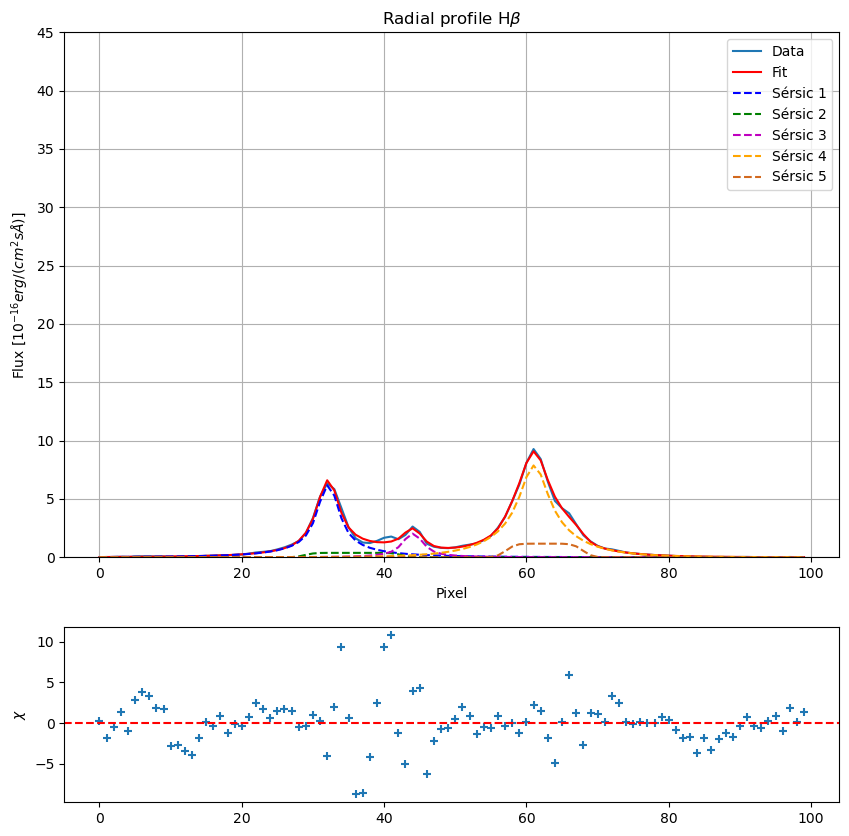

In [66]:
# Plots:
plot_curve(x_axes, params_curve_HB, radial_profile_HB, r"Radial profile H$\beta$")
plt.savefig('Radial_profile_Hbeta_curve')

## [NII]

Text(0.5, 1.0, '[NII]')

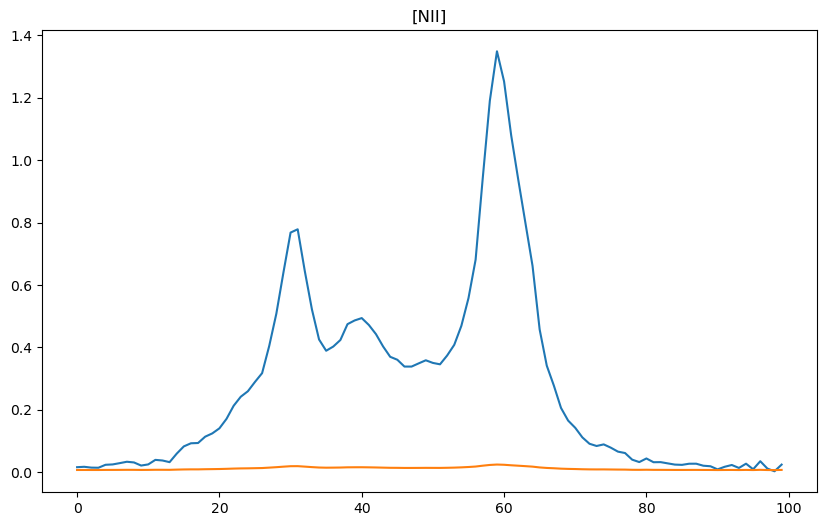

In [28]:
mask_NII = (wv > l_NII-8)*(wv < l_NII+8)
image_NII = image_cut[:, mask_NII]
image_error_NII = image_error_cut[:, mask_NII]
radial_profile_NII = np.sum(image_NII, axis = 1)
radial_profile_error_NII = np.sqrt(np.sum(image_error_NII**2, axis = 1))

plt.figure(figsize=(10, 6))
plt.plot(x_axes, radial_profile_NII)
plt.plot(x_axes, radial_profile_error_NII)
plt.title(r'[NII]')

In [29]:
# Bounds:
bounds = bounds
# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_NII)

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 476.32772023974957
differential_evolution step 2: f(x)= 325.8622718699368
differential_evolution step 3: f(x)= 21.69669325337486
differential_evolution step 4: f(x)= 21.69669325337486
differential_evolution step 5: f(x)= 6.487315462265807
differential_evolution step 6: f(x)= 6.487315462265807
differential_evolution step 7: f(x)= 6.487315462265807
differential_evolution step 8: f(x)= 6.487315462265807
differential_evolution step 9: f(x)= 6.487315462265807
differential_evolution step 10: f(x)= 6.487315462265807
differential_evolution step 11: f(x)= 6.487315462265807
differential_evolution step 12: f(x)= 6.487315462265807
differential_evolution step 13: f(x)= 6.487315462265807
differential_evolution step 14: f(x)= 6.487315462265807
differential_evolution step 15: f(x)= 6.487315462265807
differential_evolution step 16: f(x)= 6.487315462265807
differential_evolution step 17: f(x)= 6.487315462265807
differential_evolution step 18: f(x)= 6.487315462265807


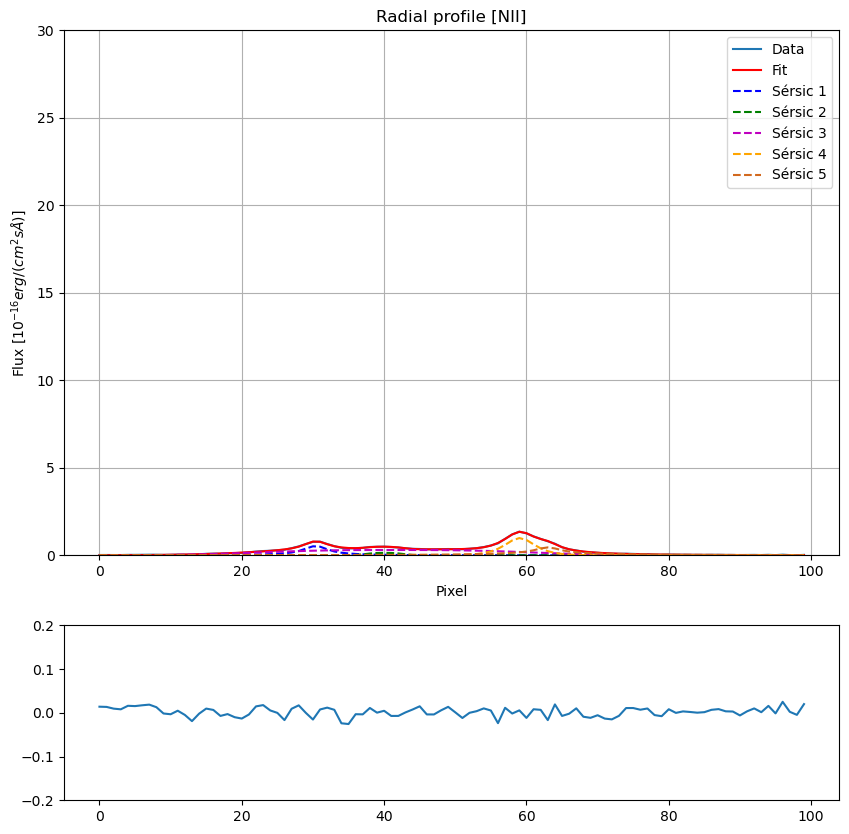

In [30]:
# Plots:
plot_diff(x_axes, best_params, radial_profile_NII, r"Radial profile [NII]")
plt.savefig('Radial_profile_NII_diff')

In [34]:
bounds_new = [
    (0, 0.07),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 10),  # r_e: da 0.1 a 50
    (0.1, 2),  # n: da 0.1 a 10
    (x_0_HA[0]-(seeing/2), x_0_HA[0]+(seeing/2)),   # x_0: posizione da 0 a 100

    (0, 0.5),
    (0, 5),
    (0.1, 2),
    (x_0_HA[1]-(seeing/2), x_0_HA[1]+(seeing/2)),

    (0, 0.5),
    (10, 25),
    (0.1, 2),
    (x_0_HA[2]-(seeing/2), x_0_HA[2]+(seeing/2)),

    (0, 0.5),
    (0, 5),
    (0.1, 2),
    (x_0_HA[3]-(seeing/2), x_0_HA[3]+(seeing/2)),

    (0, 0.05),
    (0, 50),
    (0.1, 5),
    (x_0_HA[4]-(seeing/2), x_0_HA[4]+(seeing/2))

]
lower_bounds, upper_bounds = zip(*bounds_new)
bounds_list = (list(lower_bounds), list(upper_bounds))
params_curve_NII, covariance_NII = curve_fit(model_convolved, x_axes, radial_profile_NII, p0=result.x, sigma = radial_profile_error_NII, bounds = bounds_list)#, maxfev=10000)

chi2_reduced_NII, dof_NII, chi2_NII = save_params(params_curve_NII, covariance_NII, radial_profile_NII, radial_profile_error_NII,
    x_axes, n_component, line_name="NII", output_prefix="fit")

Sérsic 1: I_e=0.0340, r_e=10.0000, n=1.9705, x_0=30.3375
Sérsic 2: I_e=0.1213, r_e=2.0554, n=0.1574, x_0=40.0554
Sérsic 3: I_e=0.1913, r_e=16.0344, n=0.3600, x_0=41.6375
Sérsic 4: I_e=0.3142, r_e=3.3539, n=0.8836, x_0=59.1006
Sérsic 5: I_e=0.0068, r_e=49.9997, n=2.7305, x_0=63.0931
[2.50399616e-02 6.52238622e+00 5.10502592e-01 6.50123681e-02
 1.55474761e-02 7.69527563e-01 3.30712728e-01 1.85146014e-01
 1.33617211e-02 9.27238003e-01 4.18122204e-02 1.67599492e+00
 5.04525499e-02 4.06343131e-01 1.17062611e-01 8.45828289e-02
 7.69295093e-03 3.67629884e+01 7.42009161e-01 2.07357997e-01]
1.2076524275994411


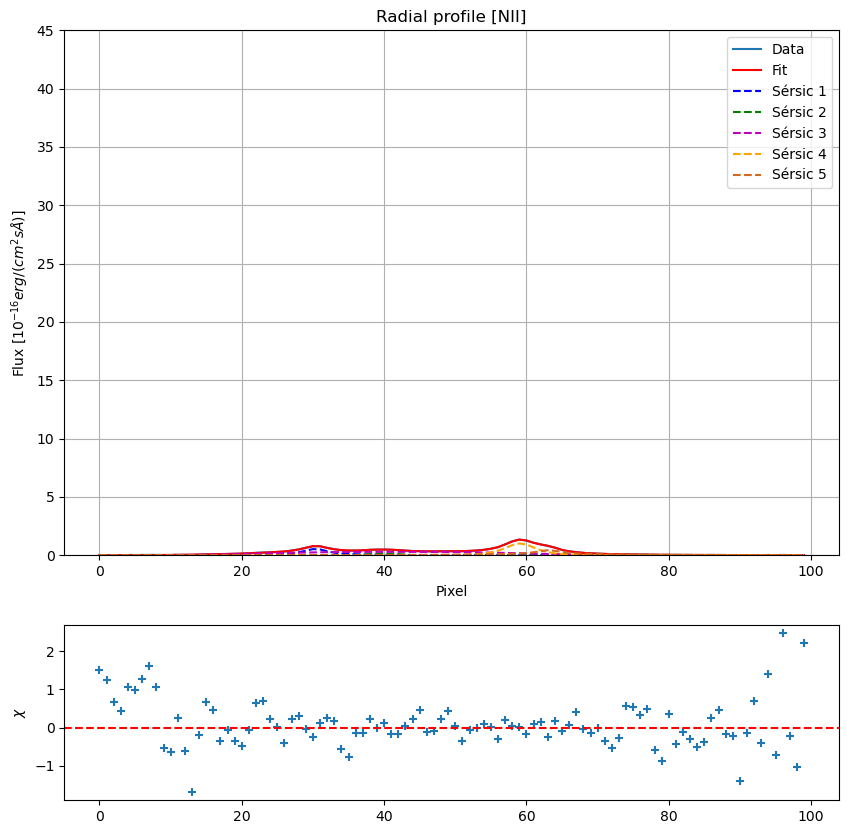

In [67]:
plot_curve(x_axes, params_curve_NII, radial_profile_NII, r"Radial profile [NII]")
plt.savefig('Radial_profile_NII_curve')

## [SII]

Text(0.5, 1.0, '[SII]')

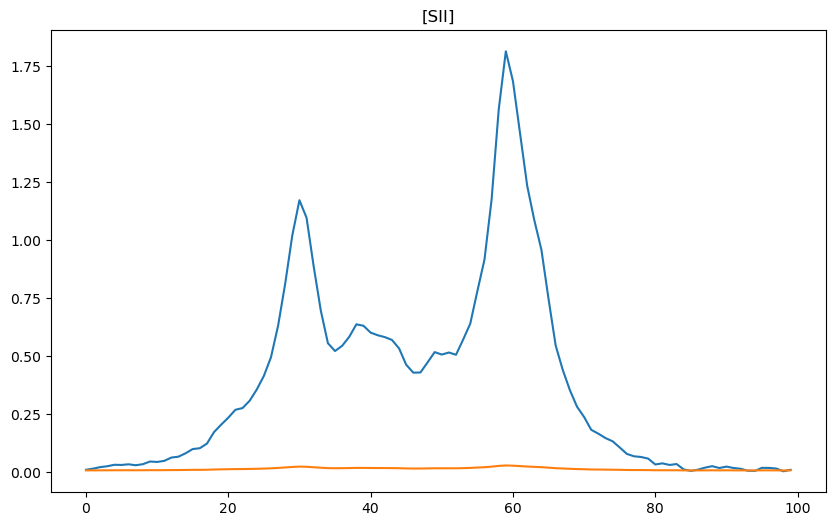

In [36]:
mask_SII = (wv > l_SII-8)*(wv < l_SII+8)
x_axes = np.arange(0, 100, 1)
image_SII = image_cut[:, mask_SII] 
image_error_SII = image_error_cut[:, mask_SII]
radial_profile_SII = np.sum(image_SII, axis = 1)
radial_profile_error_SII = np.sqrt(np.sum(image_error_SII**2, axis = 1))

plt.figure(figsize=(10, 6))
plt.plot(x_axes, radial_profile_SII)
plt.plot(x_axes, radial_profile_error_SII)
plt.title(r'[SII]')

In [37]:
# Bounds:
bounds = bounds

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_SII)

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 133.68029150321522
differential_evolution step 2: f(x)= 47.258857170940935
differential_evolution step 3: f(x)= 47.258857170940935
differential_evolution step 4: f(x)= 21.206913183903026
differential_evolution step 5: f(x)= 6.427994162766906
differential_evolution step 6: f(x)= 6.427994162766906
differential_evolution step 7: f(x)= 6.427994162766906
differential_evolution step 8: f(x)= 6.427994162766906
differential_evolution step 9: f(x)= 6.427994162766906
differential_evolution step 10: f(x)= 6.427994162766906
differential_evolution step 11: f(x)= 6.427994162766906
differential_evolution step 12: f(x)= 6.427994162766906
differential_evolution step 13: f(x)= 6.427994162766906
differential_evolution step 14: f(x)= 6.427994162766906
differential_evolution step 15: f(x)= 6.188710796091965
differential_evolution step 16: f(x)= 6.188710796091965
differential_evolution step 17: f(x)= 6.188710796091965
differential_evolution step 18: f(x)= 6.1887107960919

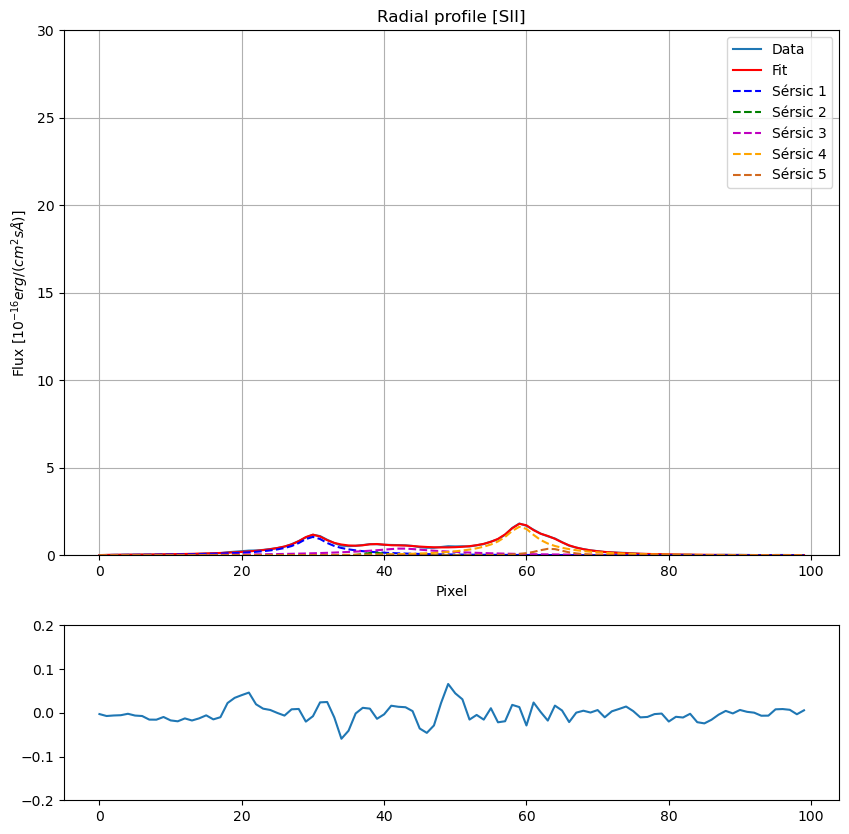

In [38]:
plot_diff(x_axes, best_params, radial_profile_SII, r"Radial profile [SII]")
plt.savefig('Radial_profile_SII_diff')

In [39]:
params_curve_SII, covariance_SII = curve_fit(model_convolved, x_axes, radial_profile_SII, p0=result.x, sigma = radial_profile_error_SII)

chi2_reduced_SII, dof_SII, chi2_SII = save_params(params_curve_SII, covariance_SII, radial_profile_SII, radial_profile_error_SII,
    x_axes, n_component, line_name="SII", output_prefix="fit")

C:\Users\ISAFA\AppData\Local\Temp\ipykernel_1448\3937479226.py:9: RuntimeWarning: invalid value encountered in power
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))
C:\Users\ISAFA\AppData\Local\Temp\ipykernel_1448\3937479226.py:22: RuntimeWarning: Use of fft convolution on input with NAN or inf results in NAN or inf output. Consider using method='direct' instead.
  conv_profile = convolve(profile, kernel, mode='same')


Sérsic 1: I_e=0.1230, r_e=13.2523, n=1.4426, x_0=30.1530
Sérsic 2: I_e=0.3182, r_e=3.2785, n=0.1473, x_0=40.6355
Sérsic 3: I_e=0.1036, r_e=3.5167, n=0.6589, x_0=48.6585
Sérsic 4: I_e=0.2415, r_e=8.6280, n=1.2918, x_0=59.2153
Sérsic 5: I_e=0.0169, r_e=15.5423, n=2.1361, x_0=63.5549
[0.00906768 0.6170791  0.05956009 0.04954153 0.01710587 0.28117449
 0.06066037 0.17789925 0.04429587 1.39326673 0.29204494 0.27854837
 0.0348379  1.34974483 0.09937701 0.07775269 0.01476892 8.80631694
 0.59342001 0.20389726]
1.4295515626433573


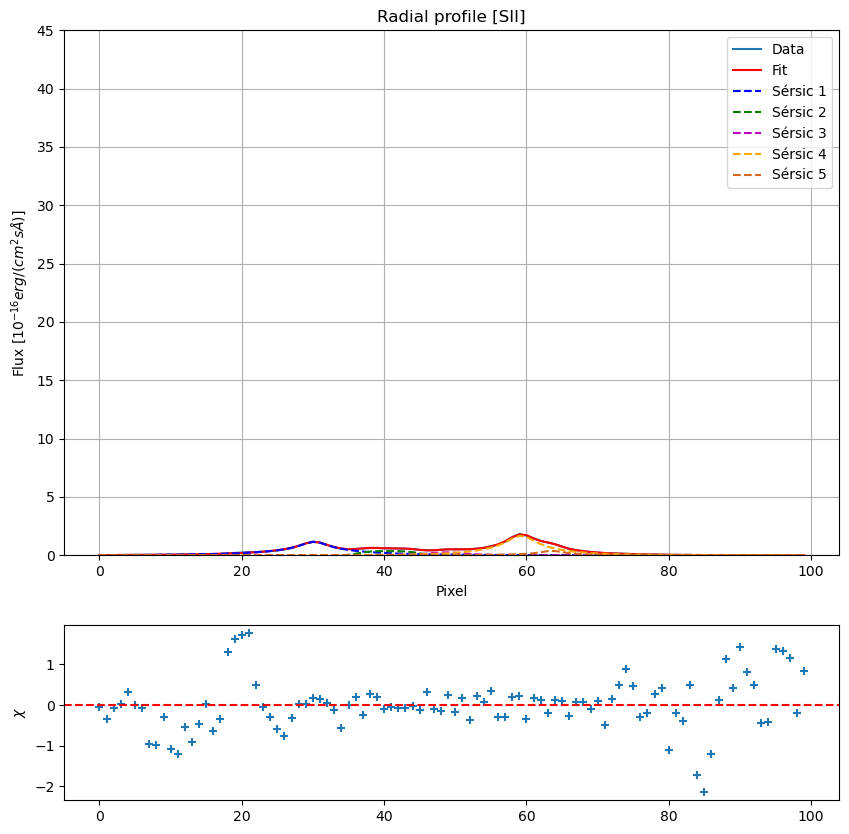

In [68]:
# Plots:
plot_curve(x_axes, params_curve_SII, radial_profile_SII, r"Radial profile [SII]")
plt.savefig('Radial_profile_SII_curve')

## [OIII]

Text(0.5, 1.0, '[OIII]')

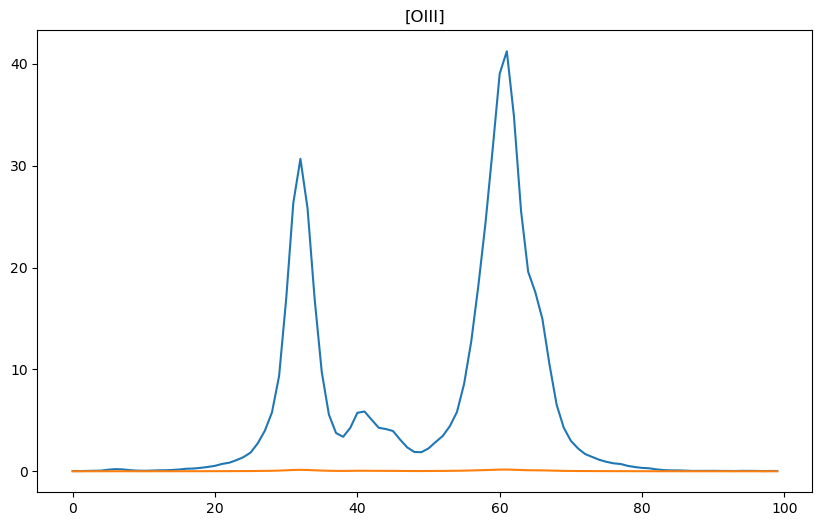

In [41]:
mask_OIII = (wv > l_OIII-8)*(wv < l_OIII+8)
image_OIII = image_cut[:, mask_OIII] 
image_error_OIII = image_error_cut[:, mask_OIII]
radial_profile_OIII = np.sum(image_OIII, axis = 1)
radial_profile_error_OIII = np.sqrt(np.sum(image_error_OIII**2, axis = 1))

plt.figure(figsize=(10, 6))
plt.plot(x_axes, radial_profile_OIII)
plt.plot(x_axes, radial_profile_error_OIII)
plt.title(r'[OIII]')

In [42]:
# Bounds:
bounds = bounds
# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_OIII)

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 3860.940452000934
differential_evolution step 2: f(x)= 2171.2827267662315
differential_evolution step 3: f(x)= 2171.2827267662315
differential_evolution step 4: f(x)= 2171.2827267662315
differential_evolution step 5: f(x)= 1875.3308964500686
differential_evolution step 6: f(x)= 1875.3308964500686
differential_evolution step 7: f(x)= 1875.3308964500686
differential_evolution step 8: f(x)= 1875.3308964500686
differential_evolution step 9: f(x)= 1799.7998100131945
differential_evolution step 10: f(x)= 1131.144937496411
differential_evolution step 11: f(x)= 1131.144937496411
differential_evolution step 12: f(x)= 1131.144937496411
differential_evolution step 13: f(x)= 1131.144937496411
differential_evolution step 14: f(x)= 1116.2684224815162
differential_evolution step 15: f(x)= 1042.3269575603929
differential_evolution step 16: f(x)= 897.602857934118
differential_evolution step 17: f(x)= 897.602857934118
differential_evolution step 18: f(x)= 897.6028579

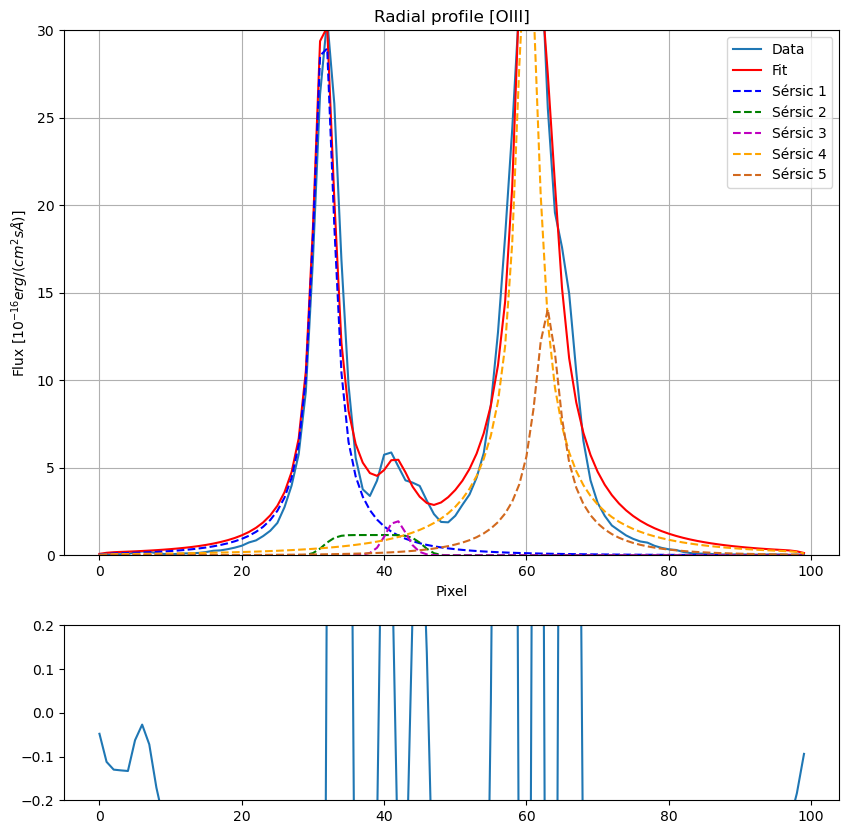

In [43]:
# Plots:
plot_diff(x_axes, best_params, radial_profile_OIII, r"Radial profile [OIII]")
plt.savefig('Radial_profile_OIII_diff')

In [44]:
lower_bounds, upper_bounds = zip(*bounds)
bounds_list = (list(lower_bounds), list(upper_bounds))
params_curve_OIII, covariance_OIII = curve_fit(model_convolved, x_axes, radial_profile_OIII, p0=result.x, sigma = radial_profile_error_OIII, bounds = bounds_list, maxfev=10000)


chi2_reduced_OIII, dof_OIII, chi2_OIII = save_params(params_curve_OIII, covariance_OIII, radial_profile_OIII, radial_profile_error_OIII,
    x_axes, n_component, line_name="OIII", output_prefix="fit")

Sérsic 1: I_e=1.0000, r_e=8.8164, n=2.8338, x_0=31.5163
Sérsic 2: I_e=1.0000, r_e=6.3700, n=0.1000, x_0=38.8723
Sérsic 3: I_e=0.4158, r_e=6.2794, n=1.3771, x_0=41.6386
Sérsic 4: I_e=1.0000, r_e=12.2968, n=2.7995, x_0=59.6755
Sérsic 5: I_e=1.0000, r_e=8.8075, n=2.3022, x_0=63.0393
[ 0.7942564   4.37104806  1.12330569  0.13138223  2.61808638 35.60343986
  0.76862684 27.15606577  2.02347198 21.02841103  3.31192701  0.90914107
  2.04829981 18.81974895  1.54654     0.21894348  2.66363032 16.84442808
  2.03374669  0.3858901 ]
462.62402080847886


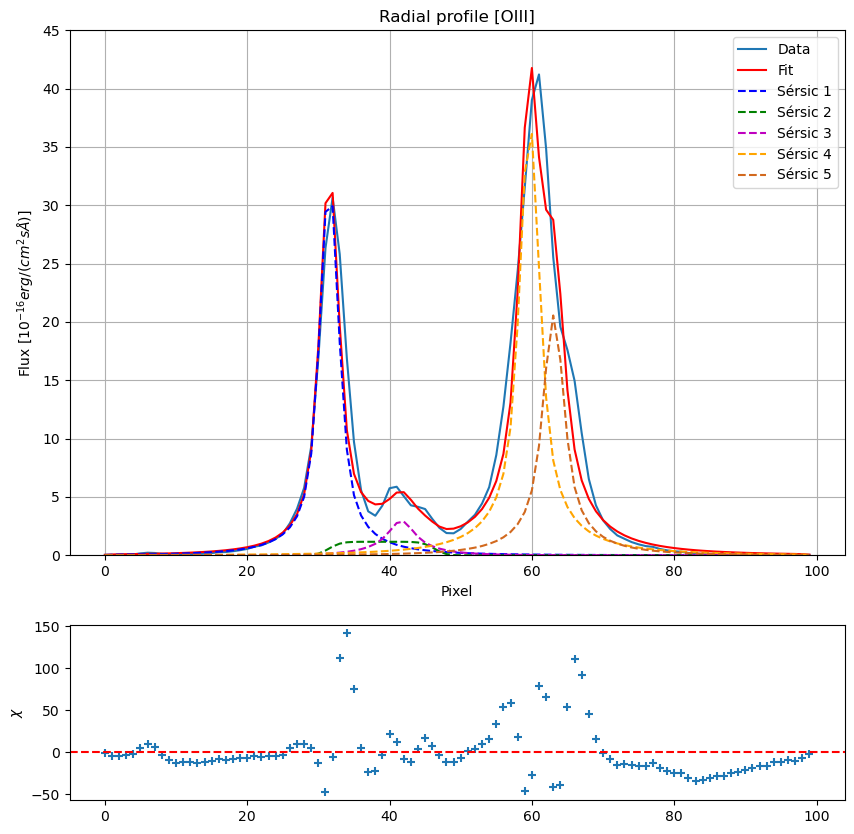

In [69]:
plot_curve(x_axes, params_curve_OIII, radial_profile_OIII, r"Radial profile [OIII]")
plt.savefig('Radial_profile_OIII_curve')

In [46]:
chi_red = [chi2_reduced_HA, chi2_reduced_HB, chi2_reduced_NII, chi2_reduced_SII, chi2_reduced_OIII]
dof = [dof_HA, dof_HB, dof_NII, dof_SII, dof_OIII]
chi = [chi2_HA, chi2_HB, chi2_NII, chi2_SII, chi2_OIII]

d1 = {'Name': ['Halpha', 'Hbeta', 'NII', 'SII', 'OIII'], 'Chi squared': chi,
      'Dof': dof, 'Chi reduced': chi_red}
df1 = pd.DataFrame(data=d1)
df1.to_csv("Chi_squared_curve_fit.csv", index= False)

## Continuum 1

Text(0.5, 1.0, 'Continuum 1')

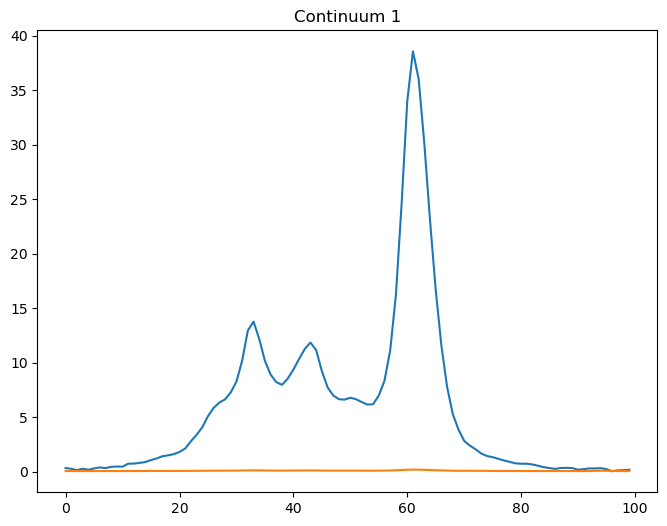

In [47]:
mask_continuum_1 = (wv > 4500)*(wv < 4800)
image_continuum_1 = image_cut[:, mask_continuum_1]
image_error_continuum_1 = image_error_cut[:, mask_continuum_1]
radial_profile_continuum_1 = np.sum(image_continuum_1, axis = 1)
radial_profile_error_continuum_1 = np.sqrt(np.sum(image_error_continuum_1**2, axis = 1))

x_axes = np.arange(0, 100, 1)
plt.figure(figsize=(8,6))
plt.plot(x_axes, radial_profile_continuum_1)
plt.plot(x_axes, radial_profile_error_continuum_1)
plt.title(r'Continuum 1')

In [48]:
# Bounds:
bounds = bounds_HA

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_continuum_1)

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 1439.9765219535595
differential_evolution step 2: f(x)= 1248.3131415143775
differential_evolution step 3: f(x)= 1221.317879008541
differential_evolution step 4: f(x)= 524.3749924630093
differential_evolution step 5: f(x)= 524.3749924630093
differential_evolution step 6: f(x)= 524.3749924630093
differential_evolution step 7: f(x)= 524.3749924630093
differential_evolution step 8: f(x)= 524.3749924630093
differential_evolution step 9: f(x)= 524.3749924630093
differential_evolution step 10: f(x)= 455.73147450951905
differential_evolution step 11: f(x)= 454.6435936783722
differential_evolution step 12: f(x)= 394.38532572338164
differential_evolution step 13: f(x)= 394.38532572338164
differential_evolution step 14: f(x)= 243.63345823352427
differential_evolution step 15: f(x)= 243.63345823352427
differential_evolution step 16: f(x)= 243.63345823352427
differential_evolution step 17: f(x)= 243.63345823352427
differential_evolution step 18: f(x)= 243.633458

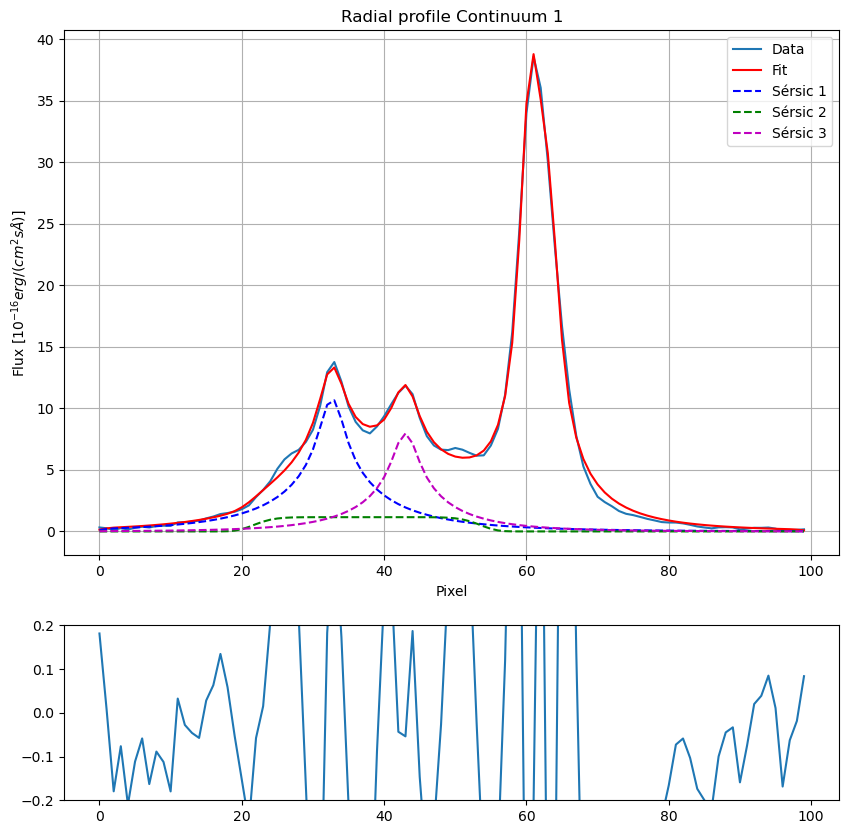

In [49]:
def plot_curve(x_axes, params_curve, radial_profile, title = ""):
    y_fit = model_convolved(x_axes, *params_curve)
    fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

    ax[0].plot(x_axes, radial_profile, label='Data')
    ax[0].plot(x_axes, y_fit, 'r-', label='Fit')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[0:4]), 'b--', label='Sérsic 1')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[4:8]), 'g--', label='Sérsic 2')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[8:12]), 'm--', label='Sérsic 3')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[12:16]), color='orange', linestyle='--', label='Sérsic 4')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[16:20]), color = 'chocolate', linestyle='--', label='Sérsic 5')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[20:24]), color = 'purple', linestyle='--', label='Sérsic 6')

    ax[0].set_xlabel("Pixel")
    ax[0].set_ylabel(r'Flux [$10^{-16} erg/(cm^2 s \AA )$]')
    ax[0].set_title(title)
    ax[0].legend()
    ax[0].grid(True)
    #ax[0].set_ylim(0, 1450)
    #ax[0].tight_layout()
    
    ax[1].scatter(x_axes, (radial_profile - y_fit)/radial_profile_error_HA, marker = '+')
    ax[1].axhline(0, color ='red', linestyle ='dashed')
    ax[1].set_ylabel(r'$\chi$')

def plot_diff(x_axes, best_params, radial_profile, title = ""):
    y_fit = model_convolved(x_axes, *best_params)

    fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

    ax[0].plot(x_axes, radial_profile, label='Data')
    ax[0].plot(x_axes, y_fit, 'r-', label='Fit')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[0:4]), 'b--', label='Sérsic 1')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[4:8]), 'g--', label='Sérsic 2')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[8:12]), 'm--', label='Sérsic 3')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[12:16]), color='orange', linestyle='--', label='Sérsic 4')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[16:20]), color = 'chocolate', linestyle='--', label='Sérsic 5')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[20:24]), color = 'purple', linestyle='--', label='Sérsic 6')

    ax[0].set_xlabel("Pixel")
    ax[0].set_ylabel(r'Flux [$10^{-16} erg/(cm^2 s \AA )$]')
    ax[0].set_title(title)
    ax[0].legend()
    ax[0].grid(True)
    #ax[0].set_ylim(0, 1450)
    #ax[0].tight_layout()
    
    ax[1].plot(x_axes, radial_profile - y_fit)
    ax[1].set_ylim(-0.2, 0.2)
    
plot_diff(x_axes, best_params, radial_profile_continuum_1, r"Radial profile Continuum 1")
plt.savefig('Radial_profile_continuum_1_diff')

In [50]:
lower_bounds, upper_bounds = zip(*bounds)
bounds_list = (list(lower_bounds), list(upper_bounds))
params_curve_continuum_1, covariance_continuum_1 = curve_fit(model_convolved, x_axes, radial_profile_continuum_1, p0=result.x, sigma = radial_profile_error_continuum_1, bounds = bounds_list, maxfev=15000)

chi2_reduced_continuum_1, dof_continuum_1, chi2_continuum_1 = save_params(params_curve_continuum_1, covariance_continuum_1, radial_profile_continuum_1, radial_profile_error_continuum_1,
    x_axes, n_component, line_name="Continuum_1", output_prefix="fit")

Sérsic 1: I_e=0.9336, r_e=16.2177, n=1.5512, x_0=32.6039
Sérsic 2: I_e=1.0000, r_e=13.8960, n=0.1000, x_0=38.2801
Sérsic 3: I_e=0.8549, r_e=13.4343, n=1.4465, x_0=43.0026
Sérsic 4: I_e=0.9993, r_e=13.3610, n=2.5740, x_0=60.4918
Sérsic 5: I_e=0.9982, r_e=7.8517, n=2.2453, x_0=63.1665
[ 0.34554645  6.10427711  0.24110923  0.13370867  0.93145652  6.14665029
  0.11991964  1.30425715  0.77579076 14.9622086   0.5990425   0.1674719
  0.85456088  9.86884238  0.58158689  0.10822324  1.37955936  8.38394651
  1.00094602  0.16968747]
22.59329871940159


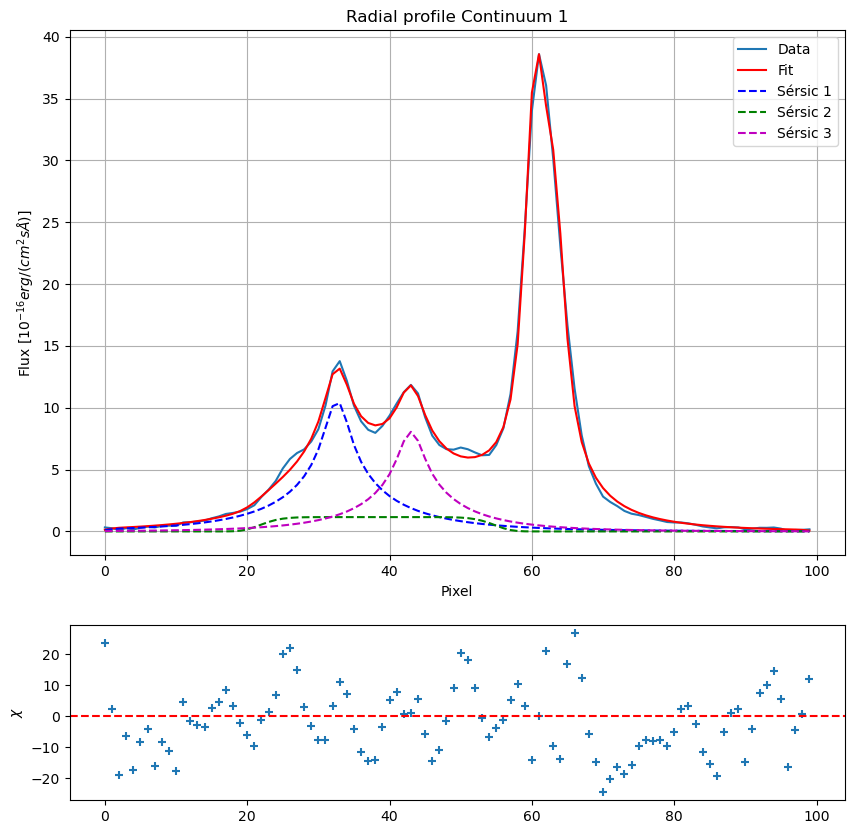

In [51]:
# Plots:
plot_curve(x_axes, params_curve_continuum_1, radial_profile_continuum_1, r"Radial profile Continuum 1")
plt.savefig('Radial_profile_continuum_1_curve')

## Continuum 2 

Text(0.5, 1.0, 'Continuum 2')

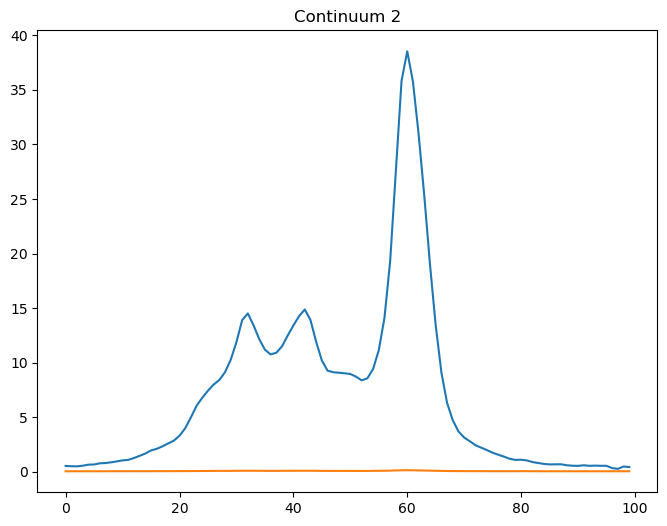

In [52]:
mask_continuum_2 = (wv > 5300)*(wv < 5800)
image_continuum_2 = image_cut[:, mask_continuum_2]
image_error_continuum_2 = image_error_cut[:, mask_continuum_2]
radial_profile_continuum_2 = np.sum(image_continuum_2, axis = 1)
radial_profile_error_continuum_2 = np.sqrt(np.sum(image_error_continuum_2**2, axis = 1))

x_axes = np.arange(0, 100, 1)
plt.figure(figsize=(8,6))
plt.plot(x_axes, radial_profile_continuum_2)
plt.plot(x_axes, radial_profile_error_continuum_2)
plt.title(r'Continuum 2')

In [53]:
# Bounds:
bounds = bounds_HA

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_continuum_2)

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 827.1116298081397
differential_evolution step 2: f(x)= 827.1116298081397
differential_evolution step 3: f(x)= 827.1116298081397
differential_evolution step 4: f(x)= 808.5219577326596
differential_evolution step 5: f(x)= 808.5219577326596
differential_evolution step 6: f(x)= 808.5219577326596
differential_evolution step 7: f(x)= 808.5219577326596
differential_evolution step 8: f(x)= 585.8842225510939
differential_evolution step 9: f(x)= 585.8842225510939
differential_evolution step 10: f(x)= 585.8842225510939
differential_evolution step 11: f(x)= 519.3208449699264
differential_evolution step 12: f(x)= 479.94395260487926
differential_evolution step 13: f(x)= 479.94395260487926
differential_evolution step 14: f(x)= 479.94395260487926
differential_evolution step 15: f(x)= 479.94395260487926
differential_evolution step 16: f(x)= 420.77714236344656
differential_evolution step 17: f(x)= 420.77714236344656
differential_evolution step 18: f(x)= 420.777142363

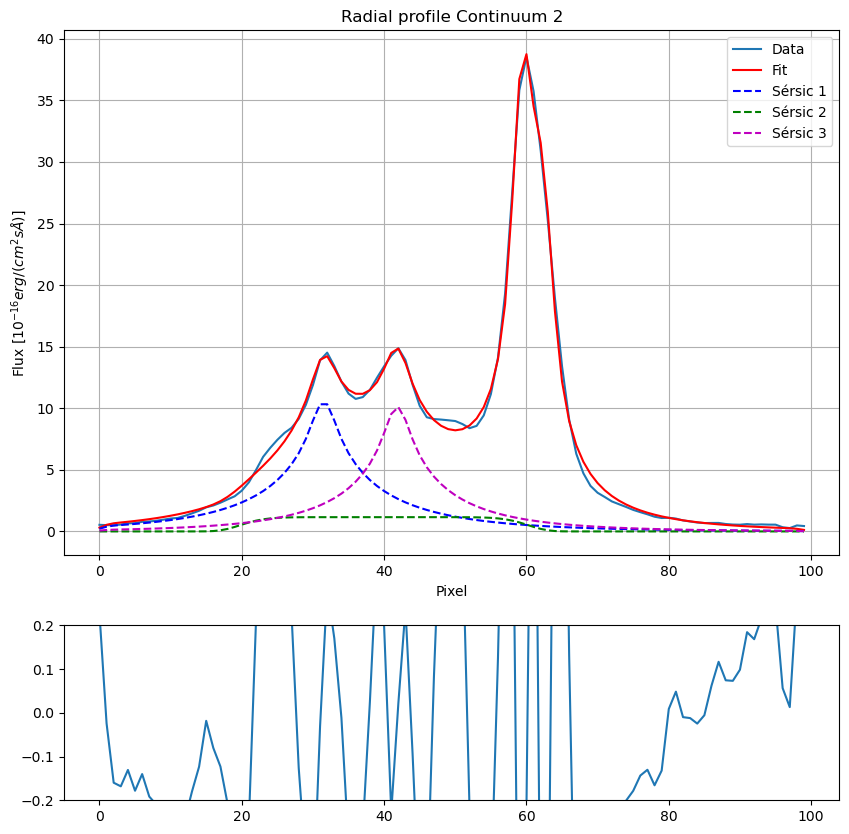

In [54]:
def plot_curve(x_axes, params_curve, radial_profile, title = ""):
    y_fit = model_convolved(x_axes, *params_curve)
    fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

    ax[0].plot(x_axes, radial_profile, label='Data')
    ax[0].plot(x_axes, y_fit, 'r-', label='Fit')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[0:4]), 'b--', label='Sérsic 1')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[4:8]), 'g--', label='Sérsic 2')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[8:12]), 'm--', label='Sérsic 3')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[12:16]), color='orange', linestyle='--', label='Sérsic 4')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[16:20]), color = 'chocolate', linestyle='--', label='Sérsic 5')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[20:24]), color = 'purple', linestyle='--', label='Sérsic 6')

    ax[0].set_xlabel("Pixel")
    ax[0].set_ylabel(r'Flux [$10^{-16} erg/(cm^2 s \AA )$]')
    ax[0].set_title(title)
    ax[0].legend()
    ax[0].grid(True)
    #ax[0].set_ylim(0, )
    #ax[0].tight_layout()
    
    ax[1].scatter(x_axes, (radial_profile - y_fit)/radial_profile_error_HA, marker = '+')
    ax[1].axhline(0, color ='red', linestyle ='dashed')
    ax[1].set_ylabel(r'$\chi$')

def plot_diff(x_axes, best_params, radial_profile, title = ""):
    y_fit = model_convolved(x_axes, *best_params)

    fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

    ax[0].plot(x_axes, radial_profile, label='Data')
    ax[0].plot(x_axes, y_fit, 'r-', label='Fit')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[0:4]), 'b--', label='Sérsic 1')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[4:8]), 'g--', label='Sérsic 2')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[8:12]), 'm--', label='Sérsic 3')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[12:16]), color='orange', linestyle='--', label='Sérsic 4')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[16:20]), color = 'chocolate', linestyle='--', label='Sérsic 5')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[20:24]), color = 'purple', linestyle='--', label='Sérsic 6')

    ax[0].set_xlabel("Pixel")
    ax[0].set_ylabel(r'Flux [$10^{-16} erg/(cm^2 s \AA )$]')
    ax[0].set_title(title)
    ax[0].legend()
    ax[0].grid(True)
    #ax[0].set_ylim(0, )
    #ax[0].tight_layout()
    
    ax[1].plot(x_axes, radial_profile - y_fit)
    ax[1].set_ylim(-0.2, 0.2)
plot_diff(x_axes, best_params, radial_profile_continuum_2, r"Radial profile Continuum 2")
plt.savefig('Radial_profile_continuum_2_diff')

In [55]:
params_curve_continuum_2, covariance_continuum_2 = curve_fit(model_convolved, x_axes, radial_profile_continuum_2, p0=result.x, 
                                                             sigma = radial_profile_error_continuum_2)#, maxfev=15000)
chi2_reduced_continuum_2, dof_continuum_2, chi2_continuum_2 = save_params(params_curve_continuum_2, covariance_continuum_2, radial_profile_continuum_2,
    radial_profile_error_continuum_2, x_axes, n_component, line_name="Continuum_2", output_prefix="fit")

C:\Users\ISAFA\AppData\Local\Temp\ipykernel_1448\3937479226.py:9: RuntimeWarning: invalid value encountered in power
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))
C:\Users\ISAFA\AppData\Local\Temp\ipykernel_1448\3937479226.py:22: RuntimeWarning: Use of fft convolution on input with NAN or inf results in NAN or inf output. Consider using method='direct' instead.
  conv_profile = convolve(profile, kernel, mode='same')


Sérsic 1: I_e=0.9156, r_e=19.8812, n=1.4695, x_0=31.6136
Sérsic 2: I_e=0.2937, r_e=21.4738, n=0.0303, x_0=41.9267
Sérsic 3: I_e=0.7041, r_e=18.7624, n=1.6361, x_0=41.7722
Sérsic 4: I_e=0.5555, r_e=27.1700, n=2.4124, x_0=59.3455
Sérsic 5: I_e=10.4716, r_e=2.8659, n=0.4855, x_0=61.4264
[ 0.18993589  6.37515135  0.14712885  0.10129491  1.10251814  1.3805233
  0.02639354  1.05675066  0.52038703 18.42954907  0.4820603   0.08656821
  0.15656421  6.95096856  0.20546339  0.16219413  1.08246813  0.14237337
  0.05537412  0.1420509 ]
9.771329022963844


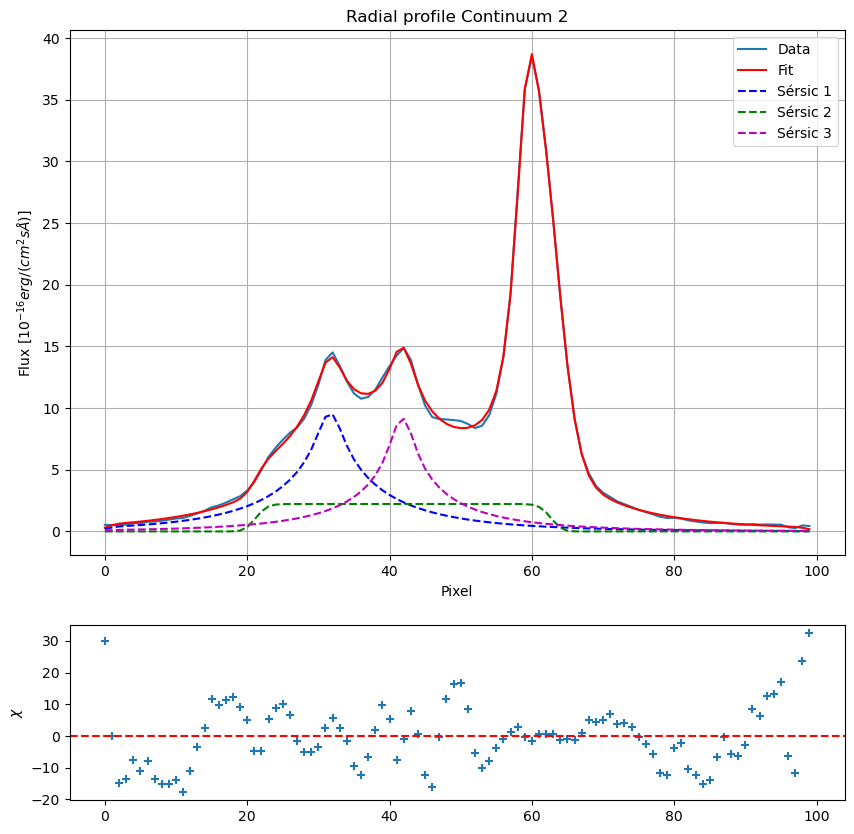

In [56]:
plot_curve(x_axes, params_curve_continuum_2, radial_profile_continuum_2, r"Radial profile Continuum 2")
plt.savefig('Radial_profile_continuum_2_curve')

##  Continuum 3

Text(0.5, 1.0, 'Continuum 3')

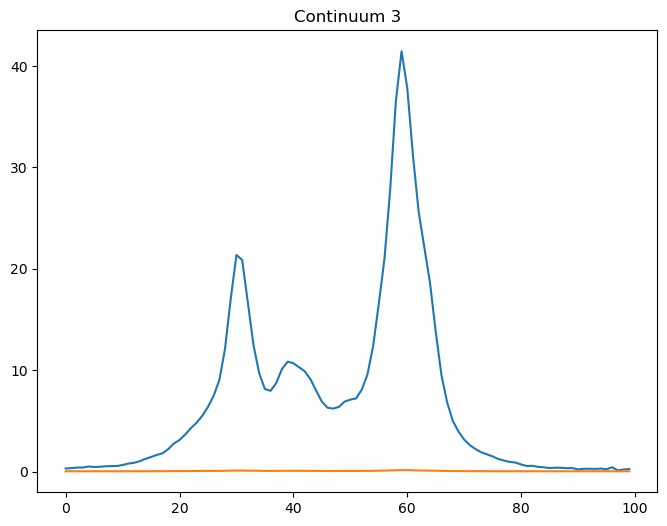

In [57]:
mask_continuum_3 = (wv > 6400)*(wv < 6700)
image_continuum_3 = image_cut[:, mask_continuum_3]
image_error_continuum_3 = image_error_cut[:, mask_continuum_3]
radial_profile_continuum_3 = np.sum(image_continuum_3, axis = 1)
radial_profile_error_continuum_3 = np.sqrt(np.sum(image_error_continuum_3**2, axis = 1))

x_axes = np.arange(0, 100, 1)
plt.figure(figsize=(8,6))
plt.plot(x_axes, radial_profile_continuum_3)
plt.plot(x_axes, radial_profile_error_continuum_3)
plt.title(r'Continuum 3')

In [58]:
 # Bounds:
bounds = bounds_HA

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_continuum_3)

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 828.6518793611054
differential_evolution step 2: f(x)= 828.6518793611054
differential_evolution step 3: f(x)= 828.6518793611054
differential_evolution step 4: f(x)= 828.6518793611054
differential_evolution step 5: f(x)= 828.6518793611054
differential_evolution step 6: f(x)= 681.901569542005
differential_evolution step 7: f(x)= 681.901569542005
differential_evolution step 8: f(x)= 681.901569542005
differential_evolution step 9: f(x)= 671.9699847893635
differential_evolution step 10: f(x)= 671.9699847893635
differential_evolution step 11: f(x)= 671.9699847893635
differential_evolution step 12: f(x)= 671.9699847893635
differential_evolution step 13: f(x)= 671.9699847893635
differential_evolution step 14: f(x)= 671.9699847893635
differential_evolution step 15: f(x)= 671.9699847893635
differential_evolution step 16: f(x)= 526.5635182580645
differential_evolution step 17: f(x)= 526.5635182580645
differential_evolution step 18: f(x)= 526.5635182580645
diff

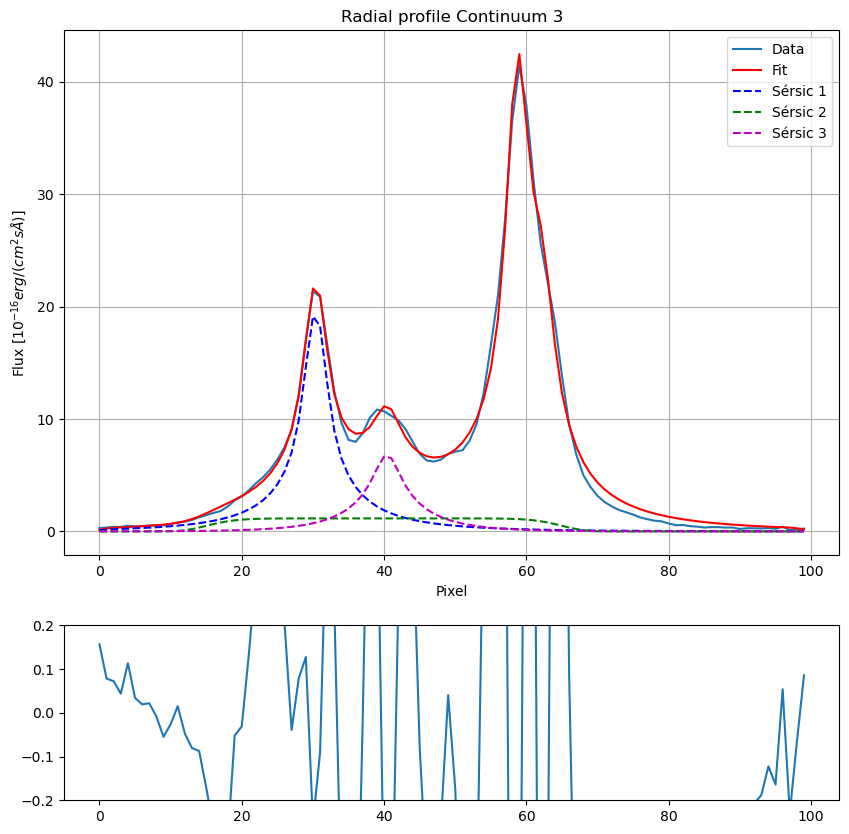

In [59]:
def plot_curve(x_axes, params_curve, radial_profile, title = ""):
    y_fit = model_convolved(x_axes, *params_curve)
    fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

    ax[0].plot(x_axes, radial_profile, label='Data')
    ax[0].plot(x_axes, y_fit, 'r-', label='Fit')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[0:4]), 'b--', label='Sérsic 1')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[4:8]), 'g--', label='Sérsic 2')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[8:12]), 'm--', label='Sérsic 3')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[12:16]), color='orange', linestyle='--', label='Sérsic 4')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[16:20]), color = 'chocolate', linestyle='--', label='Sérsic 5')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[20:24]), color = 'purple', linestyle='--', label='Sérsic 6')

    ax[0].set_xlabel("Pixel")
    ax[0].set_ylabel(r'Flux [$10^{-16} erg/(cm^2 s \AA )$]')
    ax[0].set_title(title)
    ax[0].legend()
    ax[0].grid(True)
    #ax[0].set_ylim(0, 20)
    #ax[0].tight_layout()
    
    ax[1].scatter(x_axes, (radial_profile - y_fit)/radial_profile_error_HA, marker = '+')
    ax[1].axhline(0, color ='red', linestyle ='dashed')
    ax[1].set_ylabel(r'$\chi$')

def plot_diff(x_axes, best_params, radial_profile, title = ""):
    y_fit = model_convolved(x_axes, *best_params)

    fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

    ax[0].plot(x_axes, radial_profile, label='Data')
    ax[0].plot(x_axes, y_fit, 'r-', label='Fit')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[0:4]), 'b--', label='Sérsic 1')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[4:8]), 'g--', label='Sérsic 2')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[8:12]), 'm--', label='Sérsic 3')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[12:16]), color='orange', linestyle='--', label='Sérsic 4')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[16:20]), color = 'chocolate', linestyle='--', label='Sérsic 5')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[20:24]), color = 'purple', linestyle='--', label='Sérsic 6')

    ax[0].set_xlabel("Pixel")
    ax[0].set_ylabel(r'Flux [$10^{-16} erg/(cm^2 s \AA )$]')
    ax[0].set_title(title)
    ax[0].legend()
    ax[0].grid(True)
    #ax[0].set_ylim(0, 20)
    #ax[0].tight_layout()
    
    ax[1].plot(x_axes, radial_profile - y_fit)
    ax[1].set_ylim(-0.2, 0.2)
    
plot_diff(x_axes, best_params, radial_profile_continuum_3, r"Radial profile Continuum 3")
plt.savefig('Radial_profile_continuum_3_diff')

In [60]:
params_curve_continuum_3, covariance_continuum_3 = curve_fit(model_convolved, x_axes, radial_profile_continuum_3, p0=result.x, sigma = radial_profile_error_continuum_3)

chi2_reduced_continuum_3, dof_continuum_3, chi2_continuum_3 = save_params(params_curve_continuum_3, covariance_continuum_3, radial_profile_continuum_3,
    radial_profile_error_continuum_3, x_axes, n_component, line_name="Continuum_3", output_prefix="fit")

C:\Users\ISAFA\AppData\Local\Temp\ipykernel_1448\3937479226.py:9: RuntimeWarning: invalid value encountered in power
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))
C:\Users\ISAFA\AppData\Local\Temp\ipykernel_1448\3937479226.py:22: RuntimeWarning: Use of fft convolution on input with NAN or inf results in NAN or inf output. Consider using method='direct' instead.
  conv_profile = convolve(profile, kernel, mode='same')


Sérsic 1: I_e=0.4284, r_e=23.9851, n=2.6336, x_0=30.4087
Sérsic 2: I_e=3.0342, r_e=16.7541, n=0.2320, x_0=44.3850
Sérsic 3: I_e=3.6252, r_e=2.8545, n=0.0966, x_0=40.6047
Sérsic 4: I_e=0.9915, r_e=16.3035, n=2.2202, x_0=59.0683
Sérsic 5: I_e=10.2929, r_e=3.6734, n=0.2685, x_0=60.2655
[0.0755522  3.04103272 0.13215757 0.02563984 0.17905431 0.19117891
 0.01746676 0.37473411 1.31373521 1.0370963  0.10522969 0.06728972
 0.27614878 2.15458135 0.24322215 0.02892166 0.48714898 0.05378022
 0.0242158  0.06951539]
7.965838675546284


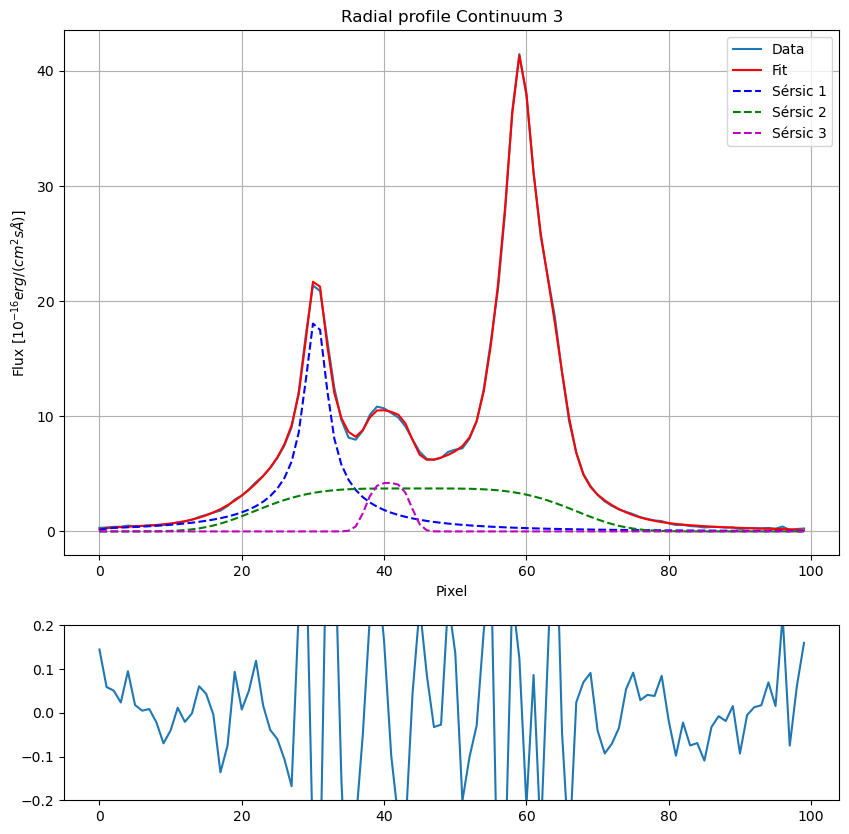

In [61]:
plot_diff(x_axes, params_curve_continuum_3, radial_profile_continuum_3, r"Radial profile Continuum 3")
plt.savefig('Radial_profile_continuum_3_curve')

## Chi squared save

In [62]:
chi_red = [chi2_reduced_HA, chi2_reduced_HB, chi2_reduced_NII, chi2_reduced_SII, chi2_reduced_OIII, 
           chi2_reduced_continuum_1, chi2_reduced_continuum_2, chi2_reduced_continuum_3]
dof = [dof_HA, dof_HB, dof_NII, dof_SII, dof_OIII, 
           dof_continuum_1, dof_continuum_2, dof_continuum_3]
chi = [chi2_HA, chi2_HB, chi2_NII, chi2_SII, chi2_OIII, 
           chi2_continuum_1, chi2_continuum_2, chi2_continuum_3]

d1 = {'Name': ['Halpha', 'Hbeta', 'NII', 'SII', 'OIII', 'Continuum 1', 'Continuum 2', 'Continuum 3'], 'Chi squared': chi,
      'Dof': dof, 'Chi reduced': chi_red}
df1 = pd.DataFrame(data=d1)
df1.to_csv("Chi_squared_curve_fit.csv", index= False)

In [63]:
bounds = [
    (0, 1),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (10, 20),   # x_0: posizione da 0 a 100

    (0, 1),
    (0, 50),
    (0.1, 10),
    (35, 45),

    (0, 1),
    (0, 50),
    (0.1, 10),
    (55, 65),

    (0, 1),
    (0, 50),
    (0.1, 10),
    (60, 70),

    (0, 1),
    (0, 50),
    (0.1, 10),
    (70, 80),

    (0, 1),
    (0, 50),
    (0.1, 10),
    (90, 100)
]

lower_bounds, upper_bounds = zip(*bounds)
bounds_list = (list(lower_bounds), list(upper_bounds))
